## 0. Mục tiêu notebook

Notebook này dùng để audit dữ liệu raw VN30. Notebook không sinh artifact processed; kết quả EDA chỉ dùng để định hướng `02_preprocess.ipynb`.


### 0.1. Nguồn dữ liệu và output figure

- Nguồn dữ liệu: `data/raw/vn30_stock_data.csv`
- Schema kỳ vọng: `date, open, high, low, close, volume, symbol`
- Figure EDA lưu tại `reports/eda/figures/`


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Setup
PROJECT_ROOT = Path.cwd().parent
DATA_RAW = PROJECT_ROOT / "data" / "raw"
OUT_FIG = PROJECT_ROOT / "reports" / "eda" / "figures"
OUT_FIG.mkdir(parents=True, exist_ok=True)

# Style
plt.style.use('default')
sns.set_palette("husl")

print(f"✓ Project root: {PROJECT_ROOT}")
print(f"✓ Data folder: {DATA_RAW}")
print(f"✓ Output folder: {OUT_FIG}")


✓ Project root: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency
✓ Data folder: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\data\raw
✓ Output folder: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\reports\eda\figures


In [2]:
# Load raw data
raw_file = DATA_RAW / "vn30_stock_data.csv"
df_raw = pd.read_csv(raw_file)

print(f"Loaded from: {raw_file}")
print(f"Shape: {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
print()
print("First few rows:")
df_raw.head()


Loaded from: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\data\raw\vn30_stock_data.csv
Shape: (43932, 7)
Columns: ['date', 'open', 'high', 'low', 'close', 'volume', 'symbol']

First few rows:


,date,open,high,low,close,volume,symbol
0,2020-01-02,6.58,6.64,6.55,6.64,1163109,ACB
1,2020-01-03,6.64,6.70,6.61,6.64,1055528,ACB
2,2020-01-06,6.64,6.64,6.49,6.49,1286035,ACB
3,2020-01-07,6.49,6.55,6.49,6.49,1050934,ACB
4,2020-01-08,6.49,6.49,6.35,6.38,2304937,ACB


In [3]:
# Ép kiểu dữ liệu
df = df_raw.copy()

# Date -> datetime
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# Symbol -> string (uppercase, strip)
df['symbol'] = df['symbol'].astype(str).str.upper().str.strip()

# Numeric columns
numeric_cols = ['open', 'high', 'low', 'close', 'volume']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("✓ Type conversion completed")
print("\nData types:")
print(df.dtypes)


✓ Type conversion completed

Data types:
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
symbol            object
dtype: object


## 1. Tổng quan dữ liệu (shape & phạm vi)

### 1.1. Kích thước dữ liệu

In [4]:
print("=== KÍCH THƯỚC DỮ LIỆU ===")
print(f"Số dòng (rows): {df.shape[0]:,}")
print(f"Số cột (columns): {df.shape[1]}")
print(f"\nCác cột: {list(df.columns)}")


=== KÍCH THƯỚC DỮ LIỆU ===
Số dòng (rows): 43,932
Số cột (columns): 7

Các cột: ['date', 'open', 'high', 'low', 'close', 'volume', 'symbol']


### 1.2. Khoảng thời gian

In [5]:
print("=== KHOẢNG THỜI GIAN ===")
print(f"Ngày đầu tiên: {df['date'].min()}")
print(f"Ngày cuối cùng: {df['date'].max()}")
print(f"Khoảng thời gian: {(df['date'].max() - df['date'].min()).days} ngày")

# Số năm
years = df['date'].dt.year.nunique()
print(f"Số năm: {years}")
print(f"Các năm: {sorted(df['date'].dt.year.unique())}")

# Số ngày giao dịch unique
trading_days = df['date'].nunique()
print(f"\nSố ngày giao dịch unique: {trading_days:,}")

# Trung bình ngày giao dịch mỗi năm
total_days = (df['date'].max() - df['date'].min()).days
print(f"Trung bình: {trading_days / years:.1f} ngày/năm")


=== KHOẢNG THỜI GIAN ===
Ngày đầu tiên: 2020-01-02 00:00:00
Ngày cuối cùng: 2025-11-28 00:00:00
Khoảng thời gian: 2157 ngày
Số năm: 6
Các năm: [2020, 2021, 2022, 2023, 2024, 2025]

Số ngày giao dịch unique: 1,476
Trung bình: 246.0 ngày/năm


### 1.3. Universe ticker

In [6]:
print("=== UNIVERSE TICKER ===")
n_symbols = df['symbol'].nunique()
symbols = sorted(df['symbol'].unique())

print(f"Số lượng ticker unique: {n_symbols}")
print(f"\nDanh sách ticker:")
print(symbols)

# VN30 chuẩn (có thể cập nhật theo thời điểm)
vn30_standard = [
    'ACB', 'BCM', 'BID', 'CTG', 'DGC', 'FPT', 'GAS', 'GVR', 'HDB', 'HPG',
    'LPB', 'MBB', 'MSN', 'MWG', 'PLX', 'SAB', 'SHB', 'SSB', 'SSI', 'STB',
    'TCB', 'TPB', 'VCB', 'VHM', 'VIB', 'VIC', 'VJC', 'VNM', 'VPB', 'VRE'
]

print(f"\n=== SO SÁNH VỚI VN30 CHUẨN ===")
print(f"VN30 chuẩn: {len(vn30_standard)} ticker")

# Ticker thừa (không thuộc VN30)
extra_symbols = set(symbols) - set(vn30_standard)
if extra_symbols:
    print(f"\nTicker THỪA (không thuộc VN30): {sorted(extra_symbols)}")
else:
    print(f"\n✓ Không có ticker thừa")

# Ticker thiếu (trong VN30 nhưng không có data)
missing_symbols = set(vn30_standard) - set(symbols)
if missing_symbols:
    print(f"\nTicker THIẾU (trong VN30 nhưng không có data): {sorted(missing_symbols)}")
else:
    print(f"\n✓ Đầy đủ tất cả ticker VN30")


=== UNIVERSE TICKER ===
Số lượng ticker unique: 30

Danh sách ticker:
['ACB', 'BCM', 'BID', 'CTG', 'DGC', 'FPT', 'GAS', 'GVR', 'HDB', 'HPG', 'LPB', 'MBB', 'MSN', 'MWG', 'PLX', 'SAB', 'SHB', 'SSB', 'SSI', 'STB', 'TCB', 'TPB', 'VCB', 'VHM', 'VIB', 'VIC', 'VJC', 'VNM', 'VPB', 'VRE']

=== SO SÁNH VỚI VN30 CHUẨN ===
VN30 chuẩn: 30 ticker

✓ Không có ticker thừa

✓ Đầy đủ tất cả ticker VN30


### 1.4. Kiểu dữ liệu & sơ lược

In [7]:
print("=== KIỂU DỮ LIỆU ===")
print(df.dtypes)

print("\n=== INFO ===")
df.info()


=== KIỂU DỮ LIỆU ===
date      datetime64[ns]
open             float64
high             float64
low              float64
close            float64
volume             int64
symbol            object
dtype: object

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43932 entries, 0 to 43931
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    43932 non-null  datetime64[ns]
 1   open    43932 non-null  float64       
 2   high    43932 non-null  float64       
 3   low     43932 non-null  float64       
 4   close   43932 non-null  float64       
 5   volume  43932 non-null  int64         
 6   symbol  43932 non-null  object        
dtypes: datetime64[ns](1), float64(4), int64(1), object(1)
memory usage: 2.3+ MB


In [8]:
print("=== VÀI DÒNG ĐẦU ===")
display(df.head(10))

print("\n=== VÀI DÒNG CUỐI ===")
display(df.tail(10))


=== VÀI DÒNG ĐẦU ===


,date,open,high,low,close,volume,symbol
0,2020-01-02,6.58,6.64,6.55,6.64,1163109,ACB
1,2020-01-03,6.64,6.70,6.61,6.64,1055528,ACB
2,2020-01-06,6.64,6.64,6.49,6.49,1286035,ACB
3,2020-01-07,6.49,6.55,6.49,6.49,1050934,ACB
4,2020-01-08,6.49,6.49,6.35,6.38,2304937,ACB
5,2020-01-09,6.41,6.52,6.41,6.46,1422248,ACB
6,2020-01-10,6.49,6.67,6.49,6.55,2371501,ACB
7,2020-01-13,6.61,6.61,6.55,6.61,1523181,ACB
8,2020-01-14,6.61,6.78,6.61,6.78,2851982,ACB
9,2020-01-15,6.78,6.78,6.70,6.72,1158657,ACB



=== VÀI DÒNG CUỐI ===


,date,open,high,low,close,volume,symbol
43922,2025-11-17,32.25,33.05,32.05,32.20,7528900,VRE
43923,2025-11-18,32.20,32.50,32.05,32.35,5069300,VRE
43924,2025-11-19,32.30,32.30,31.55,31.60,6884500,VRE
43925,2025-11-20,31.75,32.45,31.70,32.00,5225000,VRE
43926,2025-11-21,31.80,32.30,31.50,32.20,5864200,VRE
43927,2025-11-24,32.30,34.45,32.25,34.45,26444000,VRE
43928,2025-11-25,35.40,35.40,33.30,33.40,12123000,VRE
43929,2025-11-26,33.50,34.40,33.35,33.85,7893300,VRE
43930,2025-11-27,34.10,34.90,33.65,33.65,7224500,VRE
43931,2025-11-28,33.65,34.25,33.15,34.25,9244100,VRE


**Kết luận ngắn.** Raw data bao phủ giai đoạn `2020-01-02` đến `2025-11-28`, gồm `30` mã VN30 và `43,932` dòng. Schema hiện tại khớp `date, open, high, low, close, volume, symbol`.


### 1.5. Biểu đồ tăng trưởng chuẩn hóa (overview)

Biểu đồ này dùng giá `close` từ raw data để nhìn diễn biến giá tương đối theo thời gian. Mỗi mã được chuẩn hóa về mốc `100` tại ngày đầu tiên có dữ liệu, nên đây là biểu đồ mô tả tương đối chứ không phải total return chính thức.


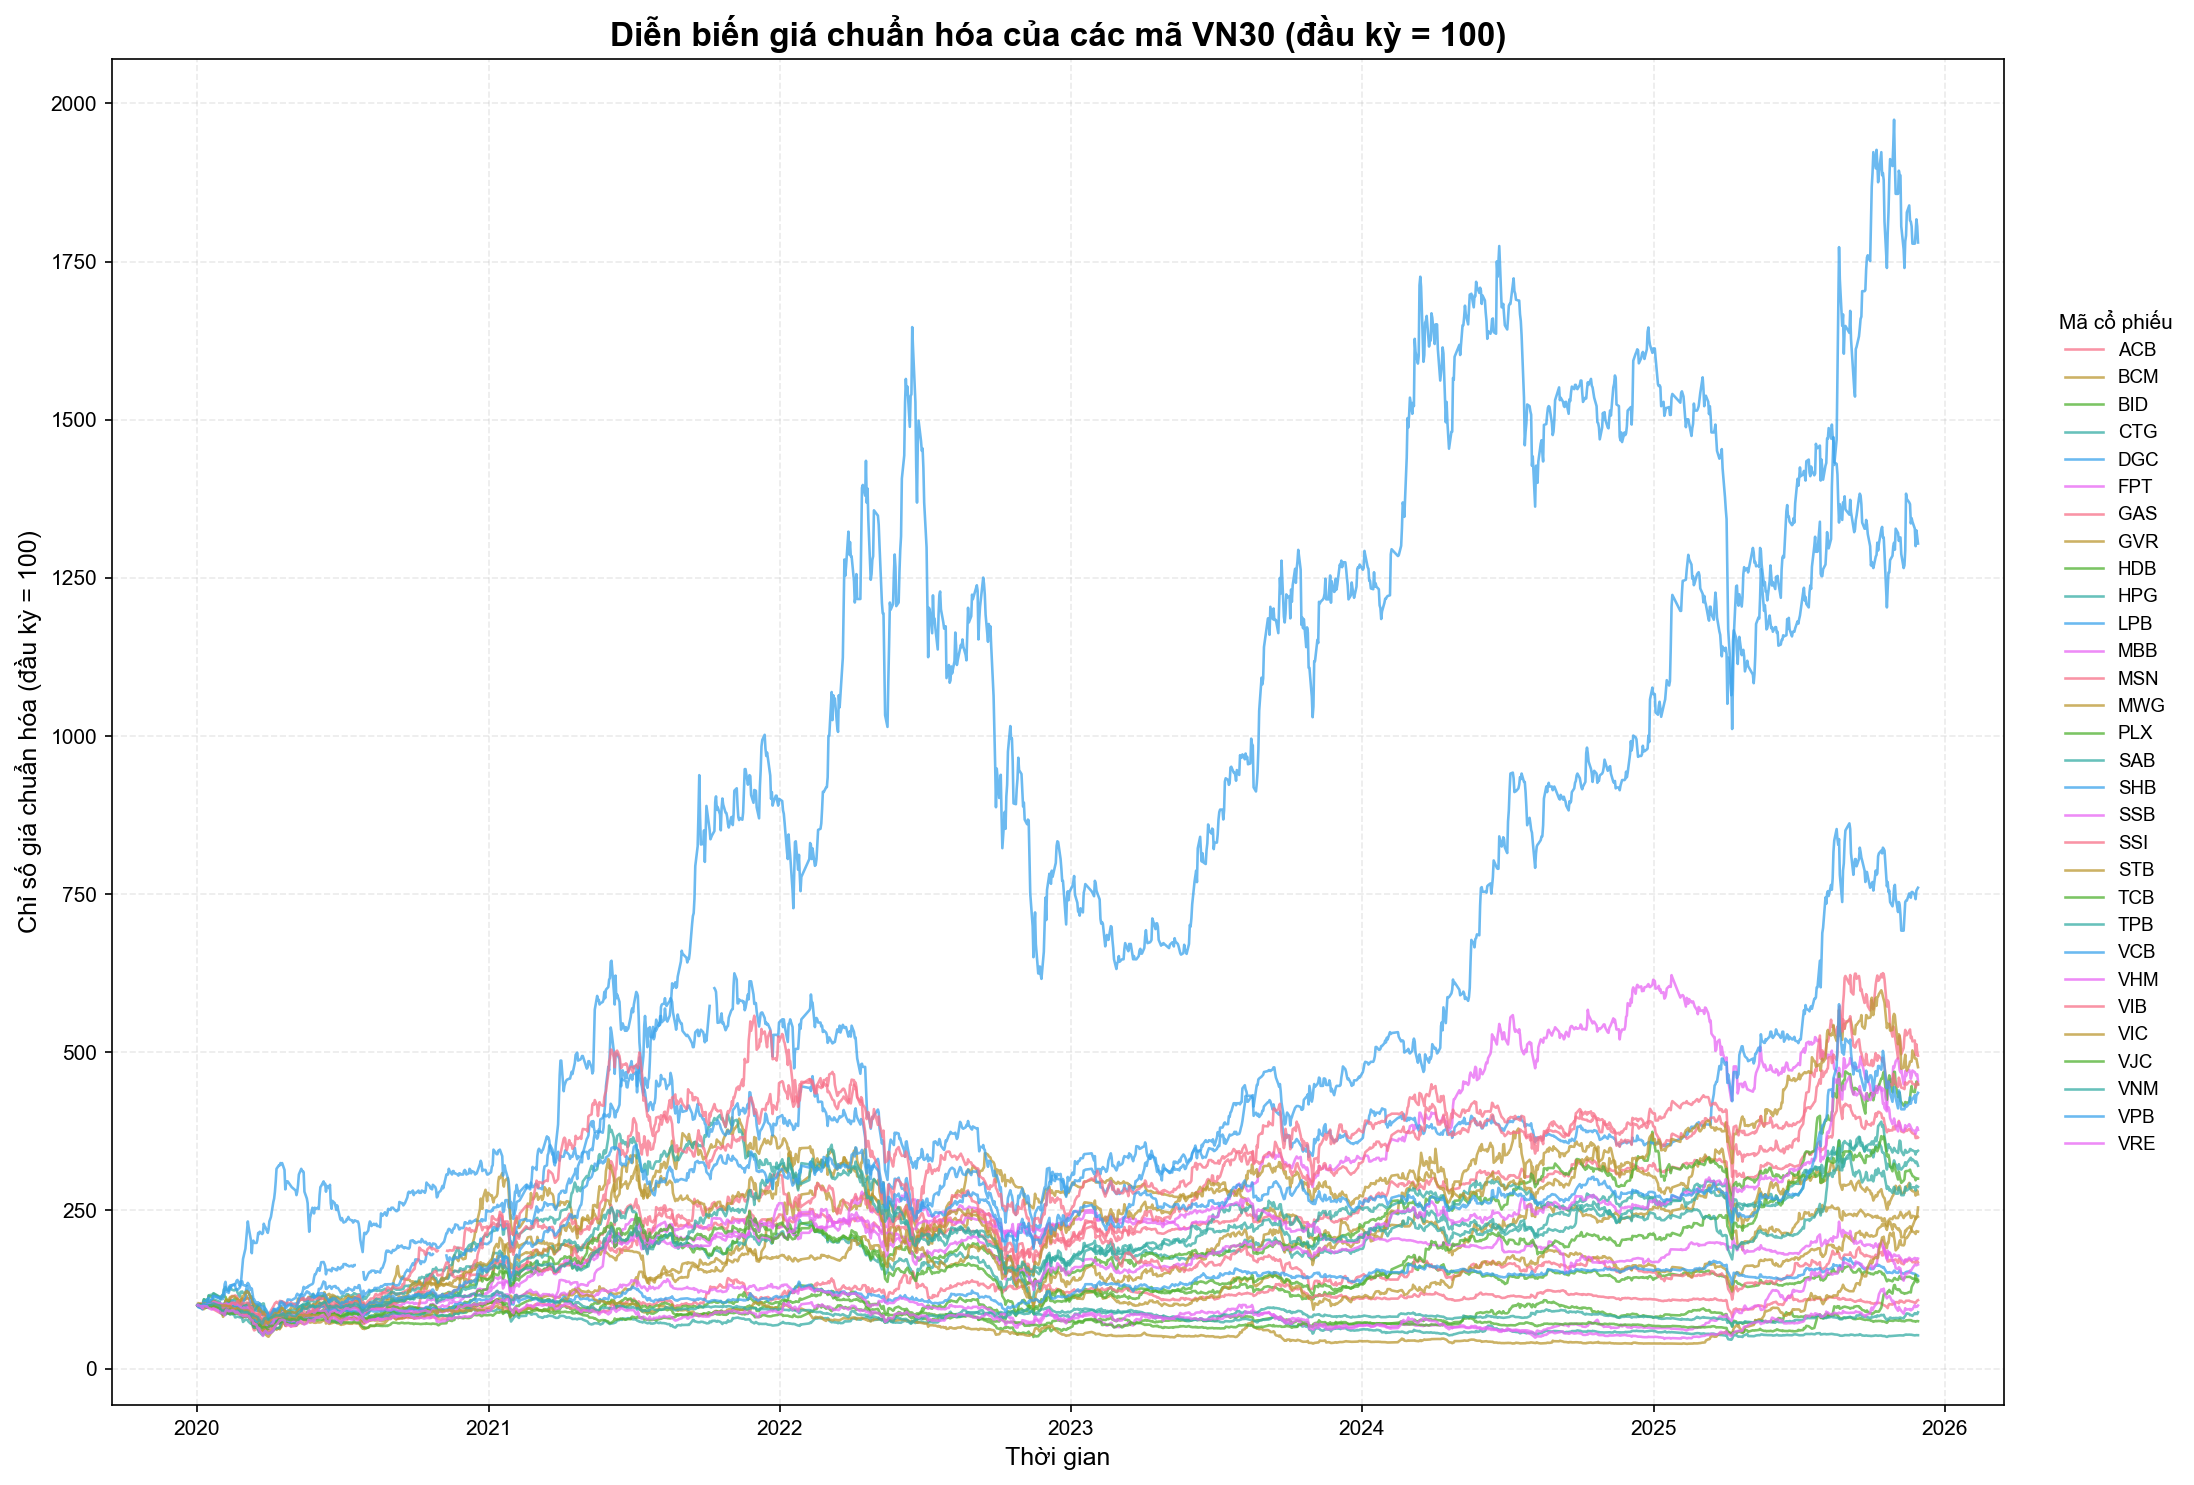

Data source: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\data\raw\vn30_stock_data.csv
Symbols on chart: 30
Date range: 2020-01-02 -> 2025-11-28
Formula: normalized_price = (close_t / first_valid_close_of_symbol) * 100
Saved figure: D:\Archive\NCKH\CODE\vn30-ver1 - Copy\.worktrees\report-figure-language-consistency\reports\eda\figures\normalized_price_growth.png


In [9]:
# Normalized price growth chart from raw data
import matplotlib.dates as mdates
from matplotlib import font_manager

preferred_fonts = ['Arial', 'DejaVu Sans', 'Liberation Sans']
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
selected_font = next((font for font in preferred_fonts if font in available_fonts), 'DejaVu Sans')

plt.rcParams['font.family'] = selected_font
plt.rcParams['font.sans-serif'] = preferred_fonts + ['sans-serif']
plt.rcParams['axes.unicode_minus'] = False

output_file = OUT_FIG / 'normalized_price_growth.png'

df_growth = (
    df[['date', 'symbol', 'close']]
    .dropna(subset=['date', 'symbol', 'close'])
    .sort_values(['date', 'symbol'])
    .copy()
)

close_matrix = (
    df_growth.pivot_table(index='date', columns='symbol', values='close', aggfunc='first')
    .sort_index()
)

first_valid_close = close_matrix.apply(
    lambda col: col.dropna().iloc[0] if col.notna().any() else pd.NA
)

normalized_price = close_matrix.divide(first_valid_close).multiply(100)

fig, ax = plt.subplots(figsize=(18, 10), dpi=150)
for symbol in normalized_price.columns:
    ax.plot(
        normalized_price.index,
        normalized_price[symbol],
        linewidth=1.25,
        alpha=0.75,
        label=symbol,
    )

ax.set_title('Diễn biến giá chuẩn hóa của các mã VN30 (đầu kỳ = 100)', fontsize=16, fontweight='bold')
ax.set_xlabel('Thời gian', fontsize=12)
ax.set_ylabel('Chỉ số giá chuẩn hóa (đầu kỳ = 100)', fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(True, linestyle='--', alpha=0.25)

ax.legend(
    title='Mã cổ phiếu',
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
    fontsize=9,
    title_fontsize=10,
)

fig.tight_layout(rect=[0, 0, 0.82, 1])
fig.savefig(output_file, dpi=300, bbox_inches='tight')
plt.show()

print(f"Data source: {DATA_RAW / 'vn30_stock_data.csv'}")
print(f"Symbols on chart: {normalized_price.shape[1]}")
print(f"Date range: {normalized_price.index.min().date()} -> {normalized_price.index.max().date()}")
print("Formula: normalized_price = (close_t / first_valid_close_of_symbol) * 100")
print(f"Saved figure: {output_file}")


**Kết luận ngắn.** Trên snapshot hiện tại, `LPB`, `DGC` và `SHB` là nhóm tăng mạnh nhất; nhóm yếu hơn gồm `SAB`, `PLX` và `VNM`. Không thấy mã nào flatline hoàn toàn, nhưng cần đọc biểu đồ này cùng với coverage theo ticker.


## 2. Duplicates & độ duy nhất của (date, ticker)

### 2.1. Kiểm tra duplicate toàn dòng

In [10]:
print("=== DUPLICATE TOÀN DÒNG ===")
n_full_dup = df.duplicated().sum()
print(f"Số dòng duplicate hoàn toàn: {n_full_dup}")

if n_full_dup > 0:
    print(f"Tỷ lệ: {n_full_dup / len(df) * 100:.2f}%")
    print("\nVí dụ các dòng duplicate:")
    display(df[df.duplicated(keep=False)].sort_values(['symbol', 'date']).head(20))
else:
    print("✓ Không có dòng duplicate hoàn toàn")


=== DUPLICATE TOÀN DÒNG ===
Số dòng duplicate hoàn toàn: 0
✓ Không có dòng duplicate hoàn toàn


### 2.2. Kiểm tra duplicate theo (date, symbol)

In [11]:
print("=== DUPLICATE THEO (DATE, SYMBOL) ===")
n_key_dup = df.duplicated(subset=['date', 'symbol']).sum()
print(f"Số dòng có (date, symbol) trùng: {n_key_dup}")

if n_key_dup > 0:
    print(f"Tỷ lệ: {n_key_dup / len(df) * 100:.2f}%")
    
    # Xem các cặp (date, symbol) bị trùng
    dup_pairs = df[df.duplicated(subset=['date', 'symbol'], keep=False)].sort_values(['symbol', 'date'])
    print(f"\nSố cặp (date, symbol) bị trùng: {dup_pairs.groupby(['date', 'symbol']).size().count()}")
    
    print("\n=== VÍ DỤ CÁC DÒNG TRÙNG ===")
    display(dup_pairs.head(20))
    
    # Kiểm tra xem giá/volume có khác nhau không
    print("\n=== PHÂN TÍCH CÁC DÒNG TRÙNG ===")
    for (date, symbol), group in dup_pairs.groupby(['date', 'symbol']):
        if len(group) > 1:
            print(f"\n{symbol} on {date}: {len(group)} dòng")
            display(group)
            
            # Check if values are identical
            if group[['open', 'high', 'low', 'close', 'volume']].nunique().max() == 1:
                print("  → Giá trị GIỐNG HỆT nhau")
            else:
                print("  → Giá trị KHÁC NHAU")
            
            # Only show first 3 examples
            if dup_pairs.groupby(['date', 'symbol']).ngroups > 3:
                break
else:
    print("✓ Không có duplicate theo (date, symbol)")
    print("✓ Mỗi mã mỗi ngày chỉ có 1 dòng duy nhất")


=== DUPLICATE THEO (DATE, SYMBOL) ===
Số dòng có (date, symbol) trùng: 0
✓ Không có duplicate theo (date, symbol)
✓ Mỗi mã mỗi ngày chỉ có 1 dòng duy nhất


**Kết luận ngắn.** Raw snapshot hiện tại không có duplicate toàn dòng và cũng không có duplicate theo khóa `(date, symbol)`. Ở `02_preprocess.ipynb`, bước dedup chủ yếu đóng vai trò guardrail cho các pass dữ liệu khác.


## 3. Missing values (NaN / null)

### 3.1. Missing theo cột

In [12]:
print("=== MISSING VALUES THEO CỘT ===")
missing_stats = pd.DataFrame({
    'Count': df.isna().sum(),
    'Percent': (df.isna().sum() / len(df) * 100).round(2)
})
missing_stats = missing_stats[missing_stats['Count'] > 0].sort_values('Count', ascending=False)

if len(missing_stats) > 0:
    print(missing_stats)
    
    # Visualize
    plt.figure(figsize=(10, 5))
    missing_stats['Percent'].plot(kind='bar', color='coral')
    plt.title('Tỷ lệ Missing Values theo cột')
    plt.ylabel('Percent (%)')
    plt.xlabel('Column')
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT_FIG / 'missing_by_column.png')
    plt.show()
else:
    print("✓ Không có missing values trong bất kỳ cột nào")


=== MISSING VALUES THEO CỘT ===
✓ Không có missing values trong bất kỳ cột nào


### 3.2. Missing theo ticker

In [13]:
print("=== MISSING VALUES THEO TICKER ===")
missing_by_symbol = []

for symbol in sorted(df['symbol'].unique()):
    symbol_data = df[df['symbol'] == symbol]
    n_rows = len(symbol_data)
    
    missing_info = {
        'symbol': symbol,
        'n_rows': n_rows,
        'missing_date': symbol_data['date'].isna().sum(),
        'missing_open': symbol_data['open'].isna().sum(),
        'missing_high': symbol_data['high'].isna().sum(),
        'missing_low': symbol_data['low'].isna().sum(),
        'missing_close': symbol_data['close'].isna().sum(),
        'missing_volume': symbol_data['volume'].isna().sum(),
    }
    missing_by_symbol.append(missing_info)

missing_by_symbol_df = pd.DataFrame(missing_by_symbol)

# Calculate total missing per symbol
missing_cols = [c for c in missing_by_symbol_df.columns if c.startswith('missing_')]
missing_by_symbol_df['total_missing'] = missing_by_symbol_df[missing_cols].sum(axis=1)

# Show symbols with missing data
symbols_with_missing = missing_by_symbol_df[missing_by_symbol_df['total_missing'] > 0]

if len(symbols_with_missing) > 0:
    print(f"Số ticker có missing: {len(symbols_with_missing)}")
    display(symbols_with_missing.sort_values('total_missing', ascending=False))
else:
    print("✓ Tất cả các ticker đều không có missing values")

print("\n=== THỐNG KÊ TỔNG QUAN ===")
print(missing_by_symbol_df[['n_rows']].describe())


=== MISSING VALUES THEO TICKER ===
✓ Tất cả các ticker đều không có missing values

=== THỐNG KÊ TỔNG QUAN ===
           n_rows
count    30.00000
mean   1464.40000
std      55.29956
min    1172.00000
25%    1473.75000
50%    1476.00000
75%    1476.00000
max    1476.00000


### 3.3. Missing theo ngày

In [14]:
print("=== MISSING VALUES BY DAY ===")

missing_fields_by_date = (
    df.set_index('date')[['open', 'high', 'low', 'close', 'volume', 'symbol']]
    .isna()
    .groupby(level=0)
    .sum()
)
missing_fields_by_date['total_missing_fields'] = missing_fields_by_date.sum(axis=1)
missing_dates = missing_fields_by_date[missing_fields_by_date['total_missing_fields'] > 0]

print(f"Days with at least one missing field: {len(missing_dates)}")
if len(missing_dates) > 0:
    display(missing_dates.sort_values('total_missing_fields', ascending=False).head(20))
else:
    print("No missing-by-day issue detected in the current raw snapshot.")


=== MISSING VALUES BY DAY ===
Days with at least one missing field: 0
No missing-by-day issue detected in the current raw snapshot.


**Kết luận ngắn.** Theo raw snapshot hiện tại, không có missing theo cột, theo ticker, hay theo ngày. Rủi ro chính của panel hiện tại vì thế không đến từ `NaN/null`.


### 3.4. Coverage theo ngày


=== UNIQUE SYMBOL COVERAGE BY DAY ===
Coverage summary:
count    1476.000000
mean       29.764228
std         0.493999
min        27.000000
25%        30.000000
50%        30.000000
75%        30.000000
max        30.000000
Name: symbol, dtype: float64
Days below 5% quantile threshold: 35
date
2020-11-03    27
2020-11-06    27
2020-11-05    27
2020-11-04    27
2020-10-30    27
2020-11-02    27
2020-10-26    28
2020-10-27    28
2020-10-28    28
2020-10-29    28
2020-03-09    28
2020-11-09    28
2020-12-02    28
2020-12-03    28
2020-12-04    28
2020-08-28    28
2020-12-07    28
2020-08-27    28
2020-08-25    28
2020-03-10    28
Name: symbol, dtype: int64


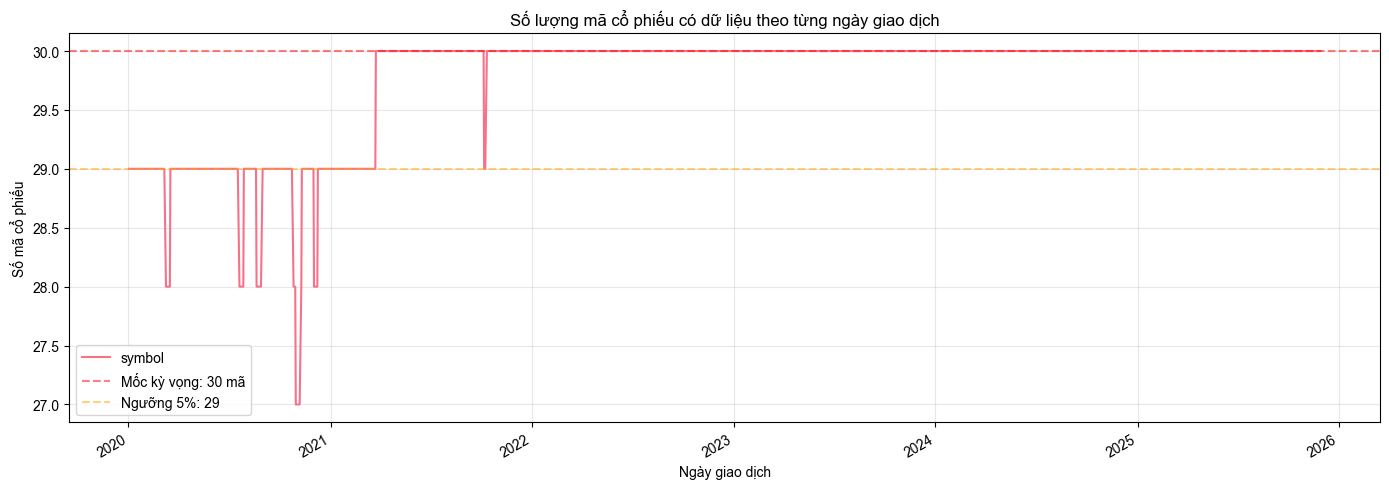

In [15]:
print("=== UNIQUE SYMBOL COVERAGE BY DAY ===")
symbols_per_day = df.groupby('date')['symbol'].nunique()

print("Coverage summary:")
print(symbols_per_day.describe())

threshold = symbols_per_day.quantile(0.05)
low_coverage_days = symbols_per_day[symbols_per_day < threshold]

if len(low_coverage_days) > 0:
    print(f"Days below 5% quantile threshold: {len(low_coverage_days)}")
    print(low_coverage_days.sort_values().head(20))
else:
    print("No abnormal low-coverage day detected.")

plt.figure(figsize=(14, 5))
symbols_per_day.plot()
plt.axhline(y=30, color='r', linestyle='--', alpha=0.5, label='Mốc kỳ vọng: 30 mã')
plt.axhline(y=threshold, color='orange', linestyle='--', alpha=0.5, label=f'Ngưỡng 5%: {threshold:.0f}')
plt.title('Số lượng mã cổ phiếu có dữ liệu theo từng ngày giao dịch')
plt.ylabel('Số mã cổ phiếu')
plt.xlabel('Ngày giao dịch')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_FIG / 'symbols_per_day.png')
plt.show()


**Kết luận ngắn.** Panel chưa đầy đủ tuyệt đối ở mọi ngày: median coverage là `30` mã nhưng có `35` ngày dưới ngưỡng 5% quantile, mức thấp nhất là `27` mã. Đây là điểm cần dùng để chốt rule coverage trong preprocess.


## 4. Check giá trị bất thường (negative, 0, kiểu dữ liệu)

### 4.1. Giá nhỏ hơn hoặc bằng 0

In [16]:
print("=== GIÁ <= 0 ===")
price_cols = ['open', 'high', 'low', 'close']
negative_price_stats = {}

for col in price_cols:
    n_zero_or_neg = (df[col] <= 0).sum()
    negative_price_stats[col] = n_zero_or_neg
    print(f"{col} <= 0: {n_zero_or_neg} dòng ({n_zero_or_neg / len(df) * 100:.2f}%)")

total_negative_price = sum(negative_price_stats.values())
if total_negative_price > 0:
    print("\n⚠ Có giá <= 0, xem ví dụ:")
    for col in price_cols:
        if negative_price_stats[col] > 0:
            print(f"\n=== {col.upper()} <= 0 ===")
            display(df[df[col] <= 0][['date', 'symbol', 'open', 'high', 'low', 'close', 'volume']].head(10))
else:
    print("\n✓ Không có giá <= 0")


=== GIÁ <= 0 ===
open <= 0: 0 dòng (0.00%)
high <= 0: 0 dòng (0.00%)
low <= 0: 0 dòng (0.00%)
close <= 0: 0 dòng (0.00%)

✓ Không có giá <= 0


### 4.2. Volume âm

In [17]:
print("=== VOLUME ÂM ===")
n_negative_volume = (df['volume'] < 0).sum()
print(f"Volume < 0: {n_negative_volume} dòng ({n_negative_volume / len(df) * 100:.2f}%)")

if n_negative_volume > 0:
    print("\n⚠ Có volume âm, xem ví dụ:")
    display(df[df['volume'] < 0][['date', 'symbol', 'open', 'high', 'low', 'close', 'volume']].head(20))
else:
    print("✓ Không có volume âm")


=== VOLUME ÂM ===
Volume < 0: 0 dòng (0.00%)
✓ Không có volume âm


### 4.3. Volume bằng 0

In [18]:
print("=== VOLUME BẰNG 0 ===")
n_zero_volume = (df['volume'] == 0).sum()
print(f"Volume == 0: {n_zero_volume} dòng ({n_zero_volume / len(df) * 100:.2f}%)")

if n_zero_volume > 0:
    print("\n=== Phân bố volume = 0 theo ticker ===")
    zero_vol_by_symbol = df[df['volume'] == 0].groupby('symbol').size().sort_values(ascending=False)
    print(zero_vol_by_symbol)
    
    print("\n=== Phân bố volume = 0 theo ngày ===")
    zero_vol_by_date = df[df['volume'] == 0].groupby('date').size().sort_values(ascending=False)
    print(zero_vol_by_date.head(20))
    
    print("\n=== Ví dụ các dòng volume = 0 ===")
    display(df[df['volume'] == 0][['date', 'symbol', 'open', 'high', 'low', 'close', 'volume']].head(20))
else:
    print("✓ Không có dòng nào volume = 0")


=== VOLUME BẰNG 0 ===
Volume == 0: 1 dòng (0.00%)

=== Phân bố volume = 0 theo ticker ===
symbol
BCM    1
dtype: int64

=== Phân bố volume = 0 theo ngày ===
date
2020-01-21    1
dtype: int64

=== Ví dụ các dòng volume = 0 ===


,date,symbol,open,high,low,close,volume
1484,2020-01-21,BCM,27.17,27.45,27.45,27.45,0


### 4.4. Kiểm tra giá trị NaN do parse lỗi

In [19]:
print("=== PARSE-ERROR CHECK ===")
print("NaN/NaT counts after conversion:")

for col in ['open', 'high', 'low', 'close', 'volume']:
    n_nan = df[col].isna().sum()
    print(f"{col}: {n_nan} NaN values")
    if n_nan > 0:
        nan_indices = df[df[col].isna()].index[:5]
        print(df_raw.loc[nan_indices, ['date', 'symbol', col]])

n_nat = df['date'].isna().sum()
print(f"date: {n_nat} NaT values")
if n_nat > 0:
    nat_indices = df[df['date'].isna()].index[:10]
    print(df_raw.loc[nat_indices, ['date', 'symbol']])


=== PARSE-ERROR CHECK ===
NaN/NaT counts after conversion:
open: 0 NaN values
high: 0 NaN values
low: 0 NaN values
close: 0 NaN values
volume: 0 NaN values
date: 0 NaT values


**Kết luận ngắn.** Raw snapshot không có giá `<= 0`, không có volume âm, và không có lỗi parse. Điểm cần lưu ý duy nhất là `1` dòng `volume == 0`, phù hợp để flag trong preprocess thay vì loại bỏ tự động.


## 5. Kiểm tra logic OHLC

### 5.1 & 5.2. Điều kiện cơ bản và thống kê vi phạm

In [20]:
print("=== OHLC RULE CHECK ===")

ohlc_rules = {
    'low <= min(open, close)': df['low'] <= df[['open', 'close']].min(axis=1),
    'high >= max(open, close)': df['high'] >= df[['open', 'close']].max(axis=1),
    'high >= low': df['high'] >= df['low'],
}

violations = {}
total_rule_violations = 0

for rule_name, rule_mask in ohlc_rules.items():
    n_violations = (~rule_mask).sum()
    violations[rule_name] = n_violations
    pct = n_violations / len(df) * 100
    total_rule_violations += n_violations
    status = 'OK' if n_violations == 0 else 'BAD'
    print(f"{status} | {rule_name}: {n_violations} violations ({pct:.3f}%)")

violation_frame = pd.DataFrame({rule_name: ~rule_mask for rule_name, rule_mask in ohlc_rules.items()})
unique_violating_rows = violation_frame.any(axis=1).sum()

print(f"Total rule violations: {total_rule_violations}")
print(f"Unique violating rows: {unique_violating_rows}")
print("Note: total rule violations may exceed unique violating rows.")


=== OHLC RULE CHECK ===
BAD | low <= min(open, close): 2 violations (0.005%)
OK | high >= max(open, close): 0 violations (0.000%)
OK | high >= low: 0 violations (0.000%)
Total rule violations: 2
Unique violating rows: 2
Note: total rule violations may exceed unique violating rows.


### 5.3. Xem ví dụ cụ thể các dòng vi phạm

In [21]:
print("=== VÍ DỤ CÁC DÒNG VI PHẠM OHLC ===")

for rule_name, rule_mask in ohlc_rules.items():
    n_violations = (~rule_mask).sum()
    
    if n_violations > 0:
        print(f"\n=== {rule_name.upper()} ({n_violations} vi phạm) ===")
        violated_rows = df[~rule_mask].copy()
        
        # Add calculated values for analysis
        violated_rows['range'] = violated_rows['high'] - violated_rows['low']
        violated_rows['max_oc'] = violated_rows[['open', 'close']].max(axis=1)
        violated_rows['min_oc'] = violated_rows[['open', 'close']].min(axis=1)
        
        display(violated_rows[['date', 'symbol', 'open', 'high', 'low', 'close', 
                              'range', 'max_oc', 'min_oc']].head(10))
        
        # Analyze severity
        if 'low' in rule_name:
            violated_rows['violation_amount'] = violated_rows['min_oc'] - violated_rows['low']
        elif 'high' in rule_name and 'max' in rule_name:
            violated_rows['violation_amount'] = violated_rows['high'] - violated_rows['max_oc']
        elif 'high >= low' in rule_name:
            violated_rows['violation_amount'] = violated_rows['low'] - violated_rows['high']
        
        if 'violation_amount' in violated_rows.columns:
            print("\nĐộ lớn vi phạm:")
            print(violated_rows['violation_amount'].describe())
            
            # Top violations
            print("\nTop 5 vi phạm nghiêm trọng nhất:")
            top_violations = violated_rows.nlargest(5, 'violation_amount')
            display(top_violations[['date', 'symbol', 'open', 'high', 'low', 'close', 'violation_amount']])


=== VÍ DỤ CÁC DÒNG VI PHẠM OHLC ===

=== LOW <= MIN(OPEN, CLOSE) (2 vi phạm) ===


,date,symbol,open,high,low,close,range,max_oc,min_oc
1484,2020-01-21,BCM,27.17,27.45,27.45,27.45,0.0,27.45,27.17
1506,2020-02-27,BCM,23.05,23.05,23.05,22.86,0.0,23.05,22.86



Độ lớn vi phạm:
count    2.00000
mean    -0.23500
std      0.06364
min     -0.28000
25%     -0.25750
50%     -0.23500
75%     -0.21250
max     -0.19000
Name: violation_amount, dtype: float64

Top 5 vi phạm nghiêm trọng nhất:


,date,symbol,open,high,low,close,violation_amount
1506,2020-02-27,BCM,23.05,23.05,23.05,22.86,-0.19
1484,2020-01-21,BCM,27.17,27.45,27.45,27.45,-0.28


**Kết luận ngắn.** Raw snapshot hiện chỉ có `2` vi phạm rule `low <= min(open, close)` và không có vi phạm ở hai rule còn lại. Các dòng này nên được flag rõ và cân nhắc loại khỏi clean OHLC set trong preprocess.


## 6. Lịch giao dịch (Trading calendar) & coverage

### 6.1. Danh sách ngày giao dịch

=== LỊCH GIAO DỊCH ===
Tổng số ngày giao dịch: 1476

=== Khoảng cách giữa các ngày giao dịch ===
count    1475.000000
mean        1.462373
std         0.987253
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max        10.000000
dtype: float64

⚠ Có 6 khoảng cách > 7 ngày:
  2020-01-22 → 2020-01-30: 8 ngày
  2021-02-09 → 2021-02-17: 8 ngày
  2022-01-28 → 2022-02-07: 10 ngày
  2023-01-19 → 2023-01-27: 8 ngày
  2024-02-07 → 2024-02-15: 8 ngày
  2025-01-24 → 2025-02-03: 10 ngày


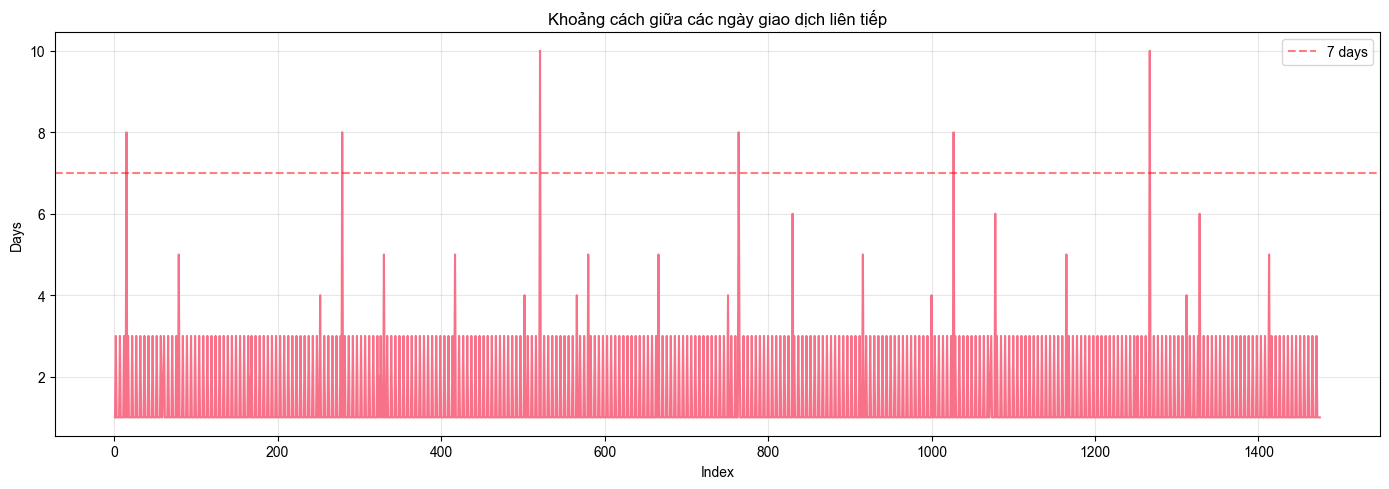

In [22]:
print("=== LỊCH GIAO DỊCH ===")

# Get all trading days sorted
trading_days = df['date'].dropna().sort_values().unique()
print(f"Tổng số ngày giao dịch: {len(trading_days)}")

# Check gaps between consecutive days
trading_days_series = pd.Series(trading_days)
gaps = trading_days_series.diff().dt.days

print("\n=== Khoảng cách giữa các ngày giao dịch ===")
print(gaps.describe())

# Find unusual gaps (> 7 days)
large_gaps = gaps[gaps > 7]
if len(large_gaps) > 0:
    print(f"\n⚠ Có {len(large_gaps)} khoảng cách > 7 ngày:")
    for idx in large_gaps.index:
        prev_day = trading_days_series.iloc[idx-1]
        curr_day = trading_days_series.iloc[idx]
        gap_days = (curr_day - prev_day).days
        print(f"  {prev_day.date()} → {curr_day.date()}: {gap_days} ngày")
else:
    print("\n✓ Không có khoảng cách bất thường")

# Visualize gaps
plt.figure(figsize=(14, 5))
gaps.plot()
plt.axhline(y=7, color='r', linestyle='--', alpha=0.5, label='7 days')
plt.title('Khoảng cách giữa các ngày giao dịch liên tiếp')
plt.ylabel('Days')
plt.xlabel('Index')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_FIG / 'trading_calendar_gaps.png')
plt.show()


**Kết luận ngắn.** Có `6` gap lớn hơn `7` ngày trong lịch giao dịch, nhưng các gap này phù hợp với các kỳ nghỉ dài như Tết. Phần trading calendar vì thế nhìn chung hợp lý.


### 6.2. Coverage theo ticker

=== COVERAGE THEO TICKER ===



=== Tổng quan coverage ===


,symbol,first_date,last_date,n_days,date_range_days,missing_close,coverage_ratio
17,SSB,2021-03-24,2025-11-28,1172,1710,0,0.685380
10,LPB,2020-01-02,2025-11-28,1466,2157,0,0.679648
1,BCM,2020-01-02,2025-11-28,1469,2157,0,0.681038
24,VIB,2020-01-02,2025-11-28,1469,2157,0,0.681038
4,DGC,2020-01-02,2025-11-28,1470,2157,0,0.681502
7,GVR,2020-01-02,2025-11-28,1470,2157,0,0.681502
0,ACB,2020-01-02,2025-11-28,1471,2157,0,0.681966
16,SHB,2020-01-02,2025-11-28,1473,2157,0,0.682893
26,VJC,2020-01-02,2025-11-28,1476,2157,0,0.684284
22,VCB,2020-01-02,2025-11-28,1476,2157,0,0.684284



⚠ Có 1 mã có history ngắn (< 80% median):


,symbol,first_date,last_date,n_days
17,SSB,2021-03-24,2025-11-28,1172



Ghi chú: Có thể do IPO muộn hoặc vào VN30 sau này


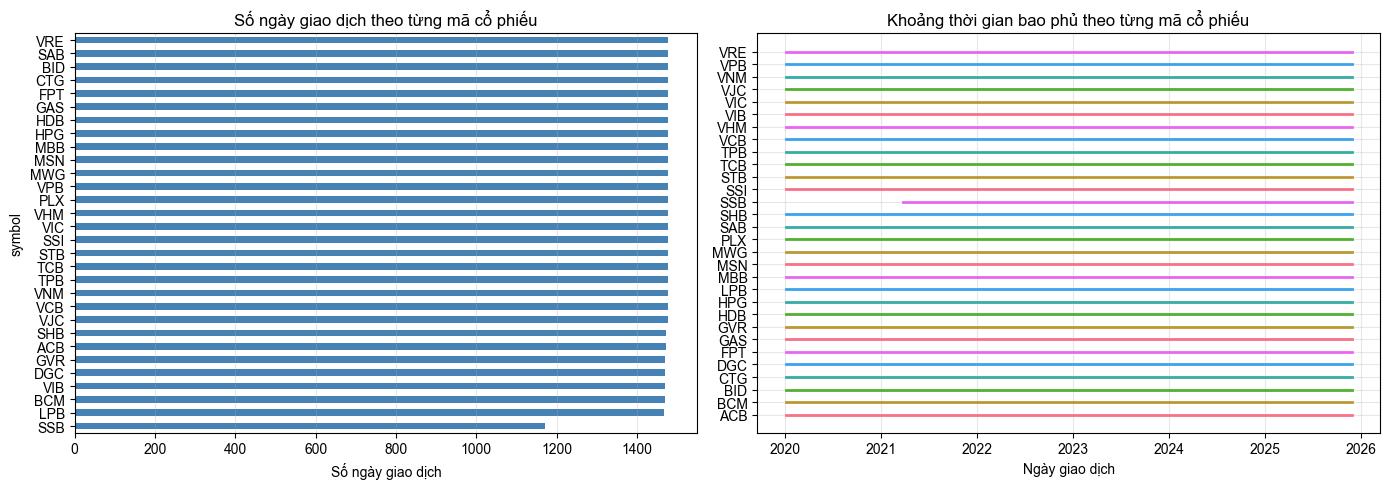

In [23]:
print("=== COVERAGE THEO TICKER ===")

coverage_stats = []
for symbol in sorted(df['symbol'].unique()):
    symbol_data = df[df['symbol'] == symbol].copy()
    symbol_data = symbol_data.dropna(subset=['date'])
    
    if len(symbol_data) > 0:
        coverage_info = {
            'symbol': symbol,
            'first_date': symbol_data['date'].min(),
            'last_date': symbol_data['date'].max(),
            'n_days': len(symbol_data),
            'date_range_days': (symbol_data['date'].max() - symbol_data['date'].min()).days,
            'missing_close': symbol_data['close'].isna().sum(),
        }
        coverage_stats.append(coverage_info)

coverage_df = pd.DataFrame(coverage_stats)
coverage_df['coverage_ratio'] = coverage_df['n_days'] / coverage_df['date_range_days']

print("\n=== Tổng quan coverage ===")
display(coverage_df.sort_values('n_days'))

# Find symbols with short history or low coverage
median_days = coverage_df['n_days'].median()
short_history = coverage_df[coverage_df['n_days'] < median_days * 0.8]

if len(short_history) > 0:
    print(f"\n⚠ Có {len(short_history)} mã có history ngắn (< 80% median):")
    display(short_history[['symbol', 'first_date', 'last_date', 'n_days']])
    print("\nGhi chú: Có thể do IPO muộn hoặc vào VN30 sau này")
else:
    print("\n✓ Tất cả các mã đều có history tương đương nhau")

# Visualize coverage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Number of days per symbol
coverage_df.set_index('symbol')['n_days'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Số ngày giao dịch theo từng mã cổ phiếu')
axes[0].set_xlabel('Số ngày giao dịch')
axes[0].grid(axis='x', alpha=0.3)

# Timeline
for idx, row in coverage_df.iterrows():
    axes[1].plot([row['first_date'], row['last_date']], [idx, idx], linewidth=2)
axes[1].set_title('Khoảng thời gian bao phủ theo từng mã cổ phiếu')
axes[1].set_xlabel('Ngày giao dịch')
axes[1].set_yticks(range(len(coverage_df)))
axes[1].set_yticklabels(coverage_df['symbol'])
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_FIG / 'coverage_by_ticker.png')
plt.show()


**Kết luận ngắn.** Coverage theo ticker không đồng đều hoàn toàn: `SSB` xuất hiện muộn từ `2021-03-24` và có history ngắn nhất (`1172` ngày). Nếu downstream cần balanced panel dài, `SSB` là mã cần lưu ý nhất.


## 7. Outlier cơ bản: giá, biên độ, volume

### 7.1. Phạm vi giá & volume

In [24]:
print("=== PHẠM VI GIÁ & VOLUME ===")

print("\n=== Thống kê Close Price ===")
print(df['close'].describe())

print("\n=== Thống kê Volume ===")
print(df['volume'].describe())

print("\n=== TOP 10 CLOSE CAO NHẤT ===")
top_high_close = df.nlargest(10, 'close')[['date', 'symbol', 'open', 'high', 'low', 'close', 'volume']]
display(top_high_close)

print("\n=== TOP 10 CLOSE THẤP NHẤT ===")
top_low_close = df.nsmallest(10, 'close')[['date', 'symbol', 'open', 'high', 'low', 'close', 'volume']]
display(top_low_close)

print("\n=== TOP 10 VOLUME CAO NHẤT ===")
top_volume = df.nlargest(10, 'volume')[['date', 'symbol', 'open', 'high', 'low', 'close', 'volume']]
display(top_volume)


=== PHẠM VI GIÁ & VOLUME ===

=== Thống kê Close Price ===
count    43932.000000
mean        38.108136
std         28.599933
min          2.110000
25%         16.207500
50%         28.200000
75%         55.910000
max        219.100000
Name: close, dtype: float64

=== Thống kê Volume ===
count    4.393200e+04
mean     6.949098e+06
std      1.094930e+07
min      0.000000e+00
25%      1.196138e+06
50%      3.062895e+06
75%      8.387176e+06
max      2.497607e+08
Name: volume, dtype: float64

=== TOP 10 CLOSE CAO NHẤT ===


,date,symbol,open,high,low,close,volume
39500,2025-11-25,VJC,205.3,219.1,203.5,219.1,3212400
39501,2025-11-26,VJC,218.5,220.0,206.9,207.8,2250800
39499,2025-11-24,VJC,194.7,205.1,193.0,204.8,2856900
39503,2025-11-28,VJC,201.0,206.8,196.8,203.5,1487300
39502,2025-11-27,VJC,207.0,207.8,193.3,202.0,4882800
39482,2025-10-30,VJC,195.1,201.2,192.6,195.5,2386700
39481,2025-10-29,VJC,189.5,196.5,189.0,195.1,2318200
39498,2025-11-21,VJC,191.0,197.1,188.6,194.6,1923700
39497,2025-11-20,VJC,177.5,190.4,177.2,190.4,3009500
39480,2025-10-28,VJC,174.3,187.5,174.3,187.5,3724300



=== TOP 10 CLOSE THẤP NHẤT ===


,date,symbol,open,high,low,close,volume
23584,2020-01-06,SHB,2.14,2.18,2.11,2.11,2225405
23585,2020-01-07,SHB,2.11,2.18,2.11,2.11,1900049
23586,2020-01-08,SHB,2.11,2.18,2.08,2.11,4952178
23583,2020-01-03,SHB,2.21,2.21,2.14,2.14,2756634
23587,2020-01-09,SHB,2.14,2.21,2.11,2.14,4564607
14793,2020-03-30,LPB,2.37,2.37,2.10,2.21,2334334
14794,2020-03-31,LPB,2.21,2.33,2.14,2.21,2241165
23582,2020-01-02,SHB,2.14,2.21,2.14,2.21,5266138
14788,2020-03-23,LPB,2.57,2.65,2.25,2.33,8131405
23588,2020-01-10,SHB,2.18,2.34,2.18,2.34,12074293



=== TOP 10 VOLUME CAO NHẤT ===


,date,symbol,open,high,low,close,volume
24952,2025-07-07,SHB,11.50,12.30,11.50,12.30,249760712
24901,2025-04-22,SHB,11.13,11.38,10.49,11.26,222754011
14654,2025-08-05,HPG,25.45,27.05,25.45,26.40,215999100
25007,2025-09-24,SHB,17.10,17.50,16.35,17.35,191797400
25018,2025-10-09,SHB,17.35,18.45,17.30,17.90,189712900
24970,2025-07-31,SHB,15.18,15.22,14.69,15.22,181370556
24973,2025-08-05,SHB,17.35,17.43,15.49,16.24,176294404
24915,2025-05-15,SHB,11.04,11.85,10.96,11.68,167986019
24986,2025-08-22,SHB,18.30,18.50,17.25,17.25,166330794
24984,2025-08-20,SHB,18.40,18.50,17.50,18.30,162635197


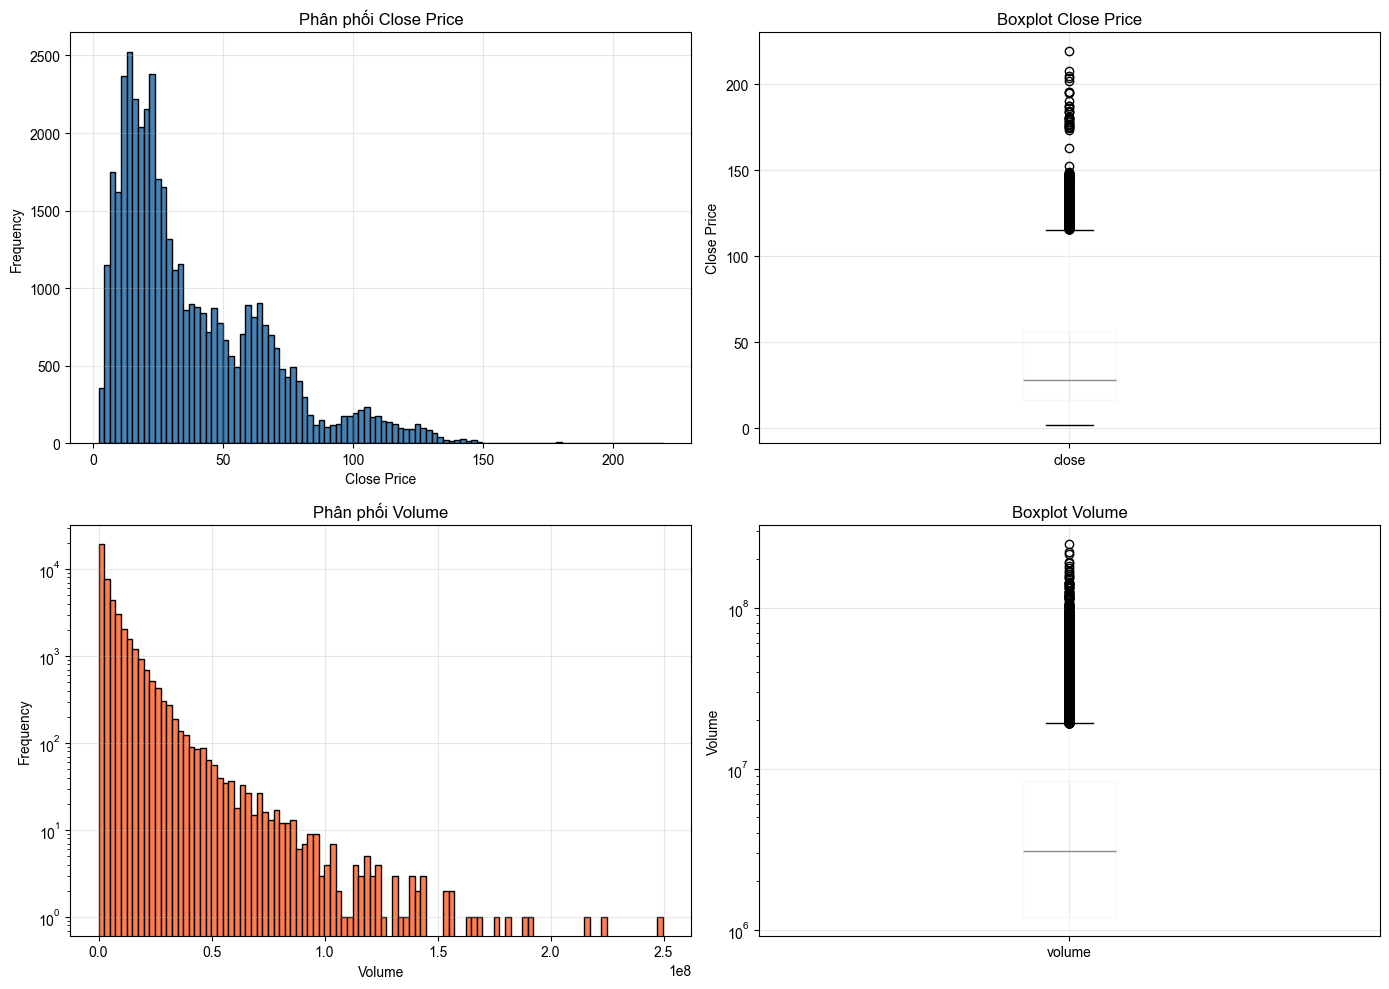

In [25]:
# Visualize distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Close price distribution
df['close'].hist(bins=100, ax=axes[0, 0], color='steelblue', edgecolor='black')
axes[0, 0].set_title('Phân phối Close Price')
axes[0, 0].set_xlabel('Close Price')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)

# Close price boxplot
df.boxplot(column='close', ax=axes[0, 1])
axes[0, 1].set_title('Boxplot Close Price')
axes[0, 1].set_ylabel('Close Price')
axes[0, 1].grid(alpha=0.3)

# Volume distribution (log scale)
df['volume'].hist(bins=100, ax=axes[1, 0], color='coral', edgecolor='black')
axes[1, 0].set_title('Phân phối Volume')
axes[1, 0].set_xlabel('Volume')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_yscale('log')
axes[1, 0].grid(alpha=0.3)

# Volume boxplot
df.boxplot(column='volume', ax=axes[1, 1])
axes[1, 1].set_title('Boxplot Volume')
axes[1, 1].set_ylabel('Volume')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_FIG / 'price_volume_distributions.png')
plt.show()


**Kết luận ngắn.** Phân phối `close` và đặc biệt là `volume` lệch phải rõ. Log-scale cho volume vì thế là cách hiển thị phù hợp cho raw snapshot hiện tại.


### 7.2. Biên độ High-Low

=== BIÊN ĐỘ HIGH-LOW ===

=== Thống kê biên độ (%) ===
count    43932.000000
mean         2.753596
std          1.799164
min          0.000000
25%          1.523810
50%          2.245410
75%          3.417131
max         19.339623
Name: range_pct, dtype: float64

Quantiles:
95%: 6.46%
99%: 9.07%

=== TOP 20 NGÀY CÓ BIÊN ĐỘ LỚN NHẤT ===


,date,symbol,open,high,low,close,range_pct
23937,2021-06-08,SHB,14.30,14.30,11.84,12.72,19.339623
23647,2020-04-10,SHB,6.50,7.18,5.98,6.98,17.191977
14788,2020-03-23,LPB,2.57,2.65,2.25,2.33,17.167382
14779,2020-03-10,LPB,2.57,3.08,2.57,3.01,16.943522
10356,2020-03-17,GVR,9.21,10.08,8.42,9.82,16.904277
23723,2020-07-29,SHB,4.50,4.90,4.11,4.74,16.666667
35125,2020-03-09,VIB,4.19,4.19,3.58,3.77,16.180371
1514,2020-03-10,BCM,20.15,23.80,20.15,23.33,15.645092
1543,2020-04-21,BCM,20.15,21.08,18.08,19.21,15.616866
59,2020-04-01,ACB,4.65,5.48,4.65,5.37,15.456238


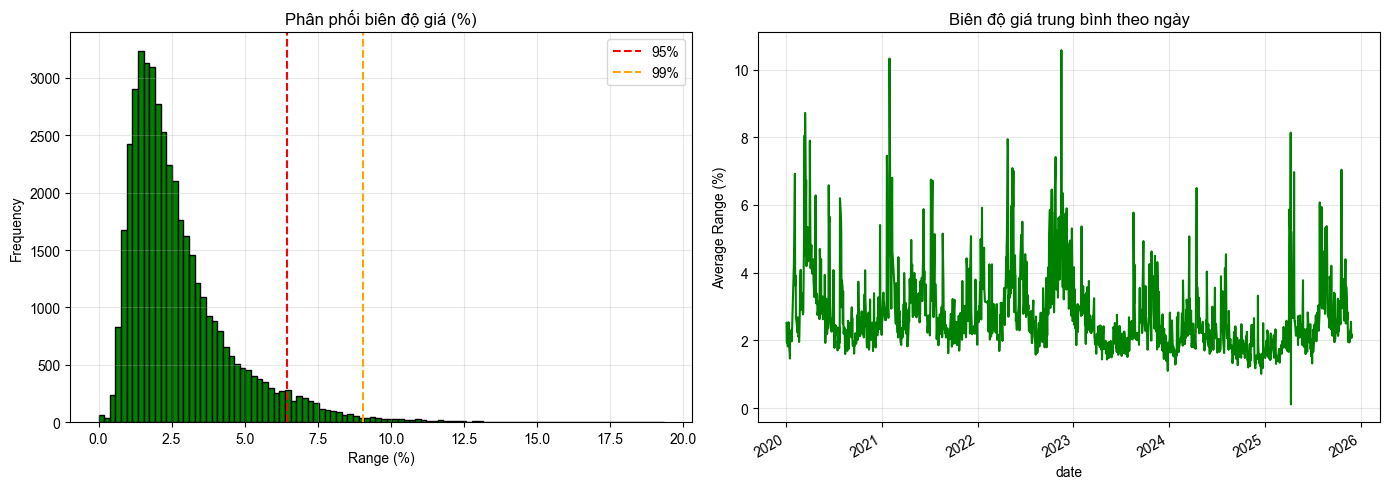

In [26]:
print("=== BIÊN ĐỘ HIGH-LOW ===")

# Calculate range
df['price_range'] = df['high'] - df['low']
df['range_pct'] = (df['price_range'] / df['close']) * 100

print("\n=== Thống kê biên độ (%) ===")
print(df['range_pct'].describe())

# Quantiles
print("\nQuantiles:")
print(f"95%: {df['range_pct'].quantile(0.95):.2f}%")
print(f"99%: {df['range_pct'].quantile(0.99):.2f}%")

print("\n=== TOP 20 NGÀY CÓ BIÊN ĐỘ LỚN NHẤT ===")
top_range = df.nlargest(20, 'range_pct')[['date', 'symbol', 'open', 'high', 'low', 'close', 'range_pct']]
display(top_range)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
df['range_pct'].hist(bins=100, ax=axes[0], color='green', edgecolor='black')
axes[0].axvline(df['range_pct'].quantile(0.95), color='r', linestyle='--', label='95%')
axes[0].axvline(df['range_pct'].quantile(0.99), color='orange', linestyle='--', label='99%')
axes[0].set_title('Phân phối biên độ giá (%)')
axes[0].set_xlabel('Range (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Time series
daily_avg_range = df.groupby('date')['range_pct'].mean()
daily_avg_range.plot(ax=axes[1], color='green')
axes[1].set_title('Biên độ giá trung bình theo ngày')
axes[1].set_ylabel('Average Range (%)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_FIG / 'price_range_analysis.png')
plt.show()


**Kết luận ngắn.** Biên độ `high-low` có tail phải và một số ngày range rất lớn. Các quan sát `range_pct` cực trị nên được flag để kiểm tra chéo thay vì loại bỏ hàng loạt.


### 7.3. Thay đổi Close giữa 2 ngày

Phần này giả định khóa `(date, symbol)` là duy nhất. Notebook đã kiểm tra duplicate key ở Section 2; nếu pass khác phát sinh duplicate, cần resolve trước khi diễn giải `daily_change`.


In [27]:
print("=== THAY ĐỔI GIÁ GIỮA 2 NGÀY ===")

# Sort by symbol and date
df_sorted = df.sort_values(['symbol', 'date']).copy()

# Calculate daily change
df_sorted['close_prev'] = df_sorted.groupby('symbol')['close'].shift(1)
df_sorted['daily_change'] = (df_sorted['close'] / df_sorted['close_prev'] - 1) * 100

print("\n=== Thống kê thay đổi giá hàng ngày (%) ===")
print(df_sorted['daily_change'].describe())

# Quantiles
print("\nQuantiles:")
print(f"1%: {df_sorted['daily_change'].quantile(0.01):.2f}%")
print(f"5%: {df_sorted['daily_change'].quantile(0.05):.2f}%")
print(f"95%: {df_sorted['daily_change'].quantile(0.95):.2f}%")
print(f"99%: {df_sorted['daily_change'].quantile(0.99):.2f}%")

# Large changes (> 50% or < -50%)
large_gains = df_sorted[df_sorted['daily_change'] > 50]
large_losses = df_sorted[df_sorted['daily_change'] < -50]

if len(large_gains) > 0:
    print(f"\n⚠ Có {len(large_gains)} ngày tăng > 50%:")
    display(large_gains[['date', 'symbol', 'close_prev', 'close', 'daily_change', 'volume']].sort_values('daily_change', ascending=False))
else:
    print("\n✓ Không có ngày tăng > 50%")

if len(large_losses) > 0:
    print(f"\n⚠ Có {len(large_losses)} ngày giảm < -50%:")
    display(large_losses[['date', 'symbol', 'close_prev', 'close', 'daily_change', 'volume']].sort_values('daily_change'))
else:
    print("\n✓ Không có ngày giảm < -50%")

# Top gains and losses
print("\n=== TOP 20 NGÀY TĂNG MẠNH NHẤT ===")
display(df_sorted.nlargest(20, 'daily_change')[['date', 'symbol', 'close_prev', 'close', 'daily_change', 'volume']])

print("\n=== TOP 20 NGÀY GIẢM MẠNH NHẤT ===")
display(df_sorted.nsmallest(20, 'daily_change')[['date', 'symbol', 'close_prev', 'close', 'daily_change', 'volume']])


=== THAY ĐỔI GIÁ GIỮA 2 NGÀY ===

=== Thống kê thay đổi giá hàng ngày (%) ===
count    43902.000000
mean         0.090014
std          2.184029
min        -15.178571
25%         -0.888518
50%          0.000000
75%          1.026695
max         12.569832
Name: daily_change, dtype: float64

Quantiles:
1%: -6.86%
5%: -3.34%
95%: 3.80%
99%: 6.87%

✓ Không có ngày tăng > 50%

✓ Không có ngày giảm < -50%

=== TOP 20 NGÀY TĂNG MẠNH NHẤT ===


,date,symbol,close_prev,close,daily_change,volume
1540,2020-04-16,BCM,17.90,20.15,12.569832,143200
1628,2020-08-31,BCM,28.20,31.48,11.631206,215370
1541,2020-04-17,BCM,20.15,22.49,11.612903,47010
1525,2020-03-25,BCM,15.09,16.77,11.133201,6000
14773,2020-03-02,LPB,2.81,3.12,11.032028,8209563
35272,2020-10-06,VIB,7.11,7.88,10.829817,4081300
1616,2020-08-04,BCM,24.64,27.17,10.267857,80441
14774,2020-03-03,LPB,3.12,3.44,10.256410,3685507
23675,2020-05-22,SHB,4.78,5.26,10.041841,13863233
23617,2020-02-27,SHB,3.19,3.51,10.031348,18183092



=== TOP 20 NGÀY GIẢM MẠNH NHẤT ===


,date,symbol,close_prev,close,daily_change,volume
14778,2020-03-09,LPB,3.36,2.85,-15.178571,6014031
1488,2020-02-03,BCM,26.24,22.68,-13.567073,16840
14788,2020-03-23,LPB,2.69,2.33,-13.382900,8131405
35125,2020-03-09,VIB,4.26,3.77,-11.502347,5896152
35135,2020-03-23,VIB,3.44,3.06,-11.046512,1989844
1543,2020-04-21,BCM,21.55,19.21,-10.858469,46900
10356,2020-03-17,GVR,10.96,9.82,-10.401460,1626550
23693,2020-06-17,SHB,6.42,5.78,-9.968847,5295572
23894,2021-04-05,SHB,10.76,9.69,-9.944238,14666101
23670,2020-05-15,SHB,6.86,6.18,-9.912536,4373756


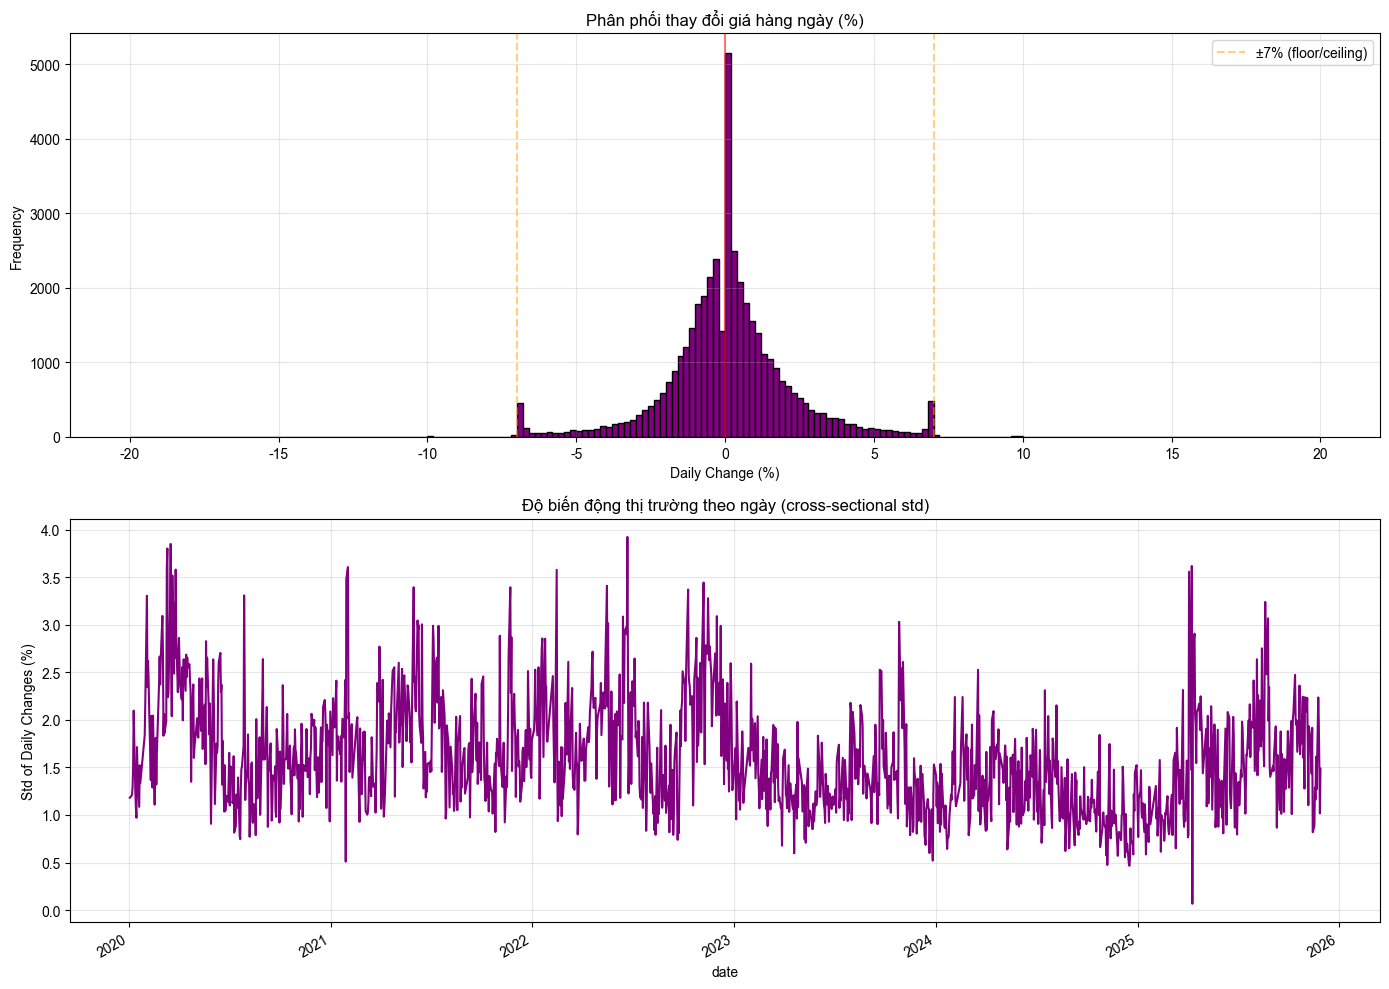

In [28]:
# Visualize daily changes
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Distribution
df_sorted['daily_change'].hist(bins=200, ax=axes[0], color='purple', edgecolor='black', range=(-20, 20))
axes[0].axvline(0, color='r', linestyle='-', alpha=0.5)
axes[0].axvline(7, color='orange', linestyle='--', alpha=0.5, label='±7% (floor/ceiling)')
axes[0].axvline(-7, color='orange', linestyle='--', alpha=0.5)
axes[0].set_title('Phân phối thay đổi giá hàng ngày (%)')
axes[0].set_xlabel('Daily Change (%)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Time series of volatility
daily_volatility = df_sorted.groupby('date')['daily_change'].std()
daily_volatility.plot(ax=axes[1], color='purple')
axes[1].set_title('Độ biến động thị trường theo ngày (cross-sectional std)')
axes[1].set_ylabel('Std of Daily Changes (%)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_FIG / 'daily_changes_analysis.png')
plt.show()


**Kết luận ngắn.** Phân phối `daily_change` có tail nhưng không có cú nhảy cực đoan `> 50%` hay `< -50%` trong raw snapshot hiện tại. Vì duplicate `(date, symbol)` bằng `0`, phép tính `close_prev` và `daily_change` ở notebook này là hợp lệ cho pass hiện tại.


## 8. Tóm tắt cuối notebook

1. **Dữ liệu raw có sạch không?** Khá sạch: đủ `30` mã, không duplicate, không missing, không lỗi parse.
2. **Vấn đề chính là gì?** Không phải duplicate hay missing; điểm cần xử lý là coverage không đều, `1` dòng `volume == 0`, và `2` dòng vi phạm OHLC.
3. **Coverage kém ở đâu?** Có `35` ngày coverage thấp và `SSB` có history ngắn nhất từ `2021-03-24`.
4. **`02_preprocess.ipynb` cần làm gì?** Loại hoặc flag dòng OHLC invalid, flag `volume == 0` và outlier, rồi chốt rule coverage theo ngày/ticker để dựng clean panel.
